In [14]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation
from agent import select_action, clever_single_action

%reload_ext autoreload
%autoreload 2

In [15]:
# Init policy Network

from agent import PolicyNet

obs_shape = (3, 5, 5)
policy_net = PolicyNet(obs_shape)
policy_net.load_state_dict(torch.load('policy_net.pth'))
policy_net.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net.to(device)


/home/delsad/SHS-Life-Science-Philosophy-Altruism/grid_simulation/cuda_env_project/.pixi/envs/default/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


PolicyNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=75, out_features=100, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=100, out_features=17, bias=True)
)

In [16]:
def get_results_imgs(simulation, iterations=50,  type1 = 'random', type2 = 'random', type3 = 'random', save_dir=None, title=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        if type1 == 'Reinforcement Learning Agent':
            action_grid = simulation.configurable_actions_grid(type1=None, type2=type2, type3=type3)

            with torch.no_grad():
                observations, obs_indices = simulation.get_deep_observations(0)
                action = select_action(policy_net, observations)
                action_grid = clever_single_action(simulation, action, obs_indices, type2, type3) 

        else:
            action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)

        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = '\n'
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'{type1.capitalize()}'),
        Patch(facecolor='blue', edgecolor='b', label=f'{type2.capitalize()}'),
        Patch(facecolor='green', edgecolor='g', label=f'{type3.capitalize()}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final Population Distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_final_distr.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'{type1.capitalize()}', color='red', linestyle='--', marker='o', markersize=4, markevery=10)
    plt.plot(np.arange(iterations), pop2_size, label=f'{type2.capitalize()}', color='blue', marker='x', markersize=4, markevery=7)
    plt.plot(np.arange(iterations), pop3_size, label=f'{type3.capitalize()}', color='green', marker='s', markersize=4, markevery=13)
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_time_plot.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_4155969/570399679.py:5: SyntaxWarning: invalid escape sequence '\%'
  all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'


Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.49207305908203
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.49207305908203

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



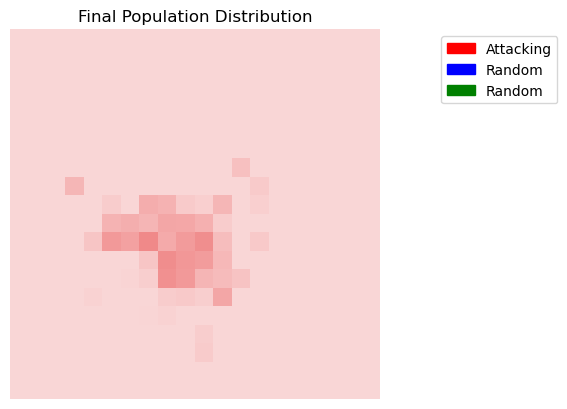

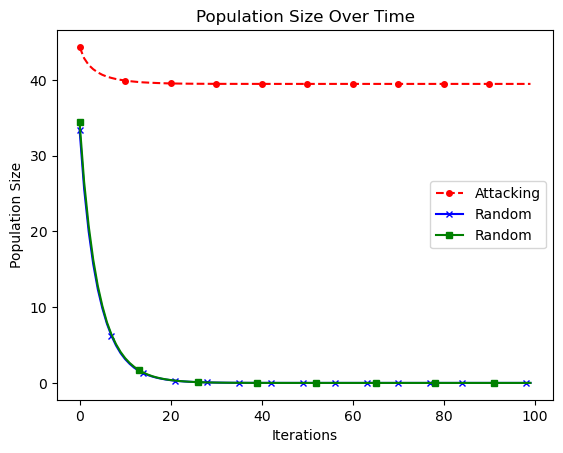

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 5.94452217228536e-07
Population 2: random - 1.1984467164438684e-05
Population 3: random - 1.2452625924197491e-05

Total fitness: 2.5031546101672575e-05

Final population %'s fitness:
Population 1: giving - 2.37%
Population 2: random - 47.88%
Population 3: random - 49.75%



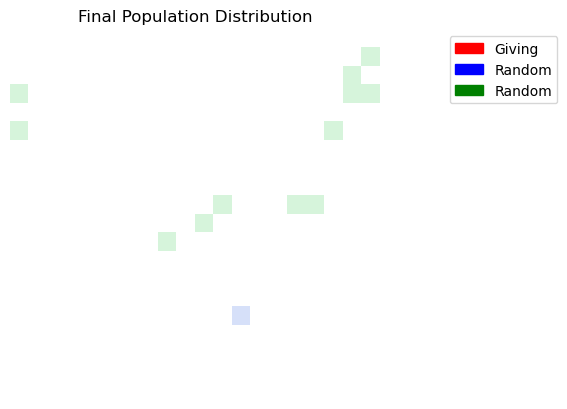

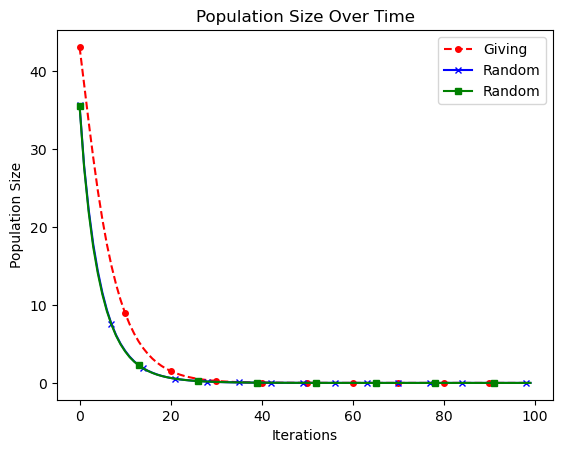

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 6.825884923955527e-08
Population 2: random - 5.966702246951172e-06
Population 3: random - 5.8189084484183695e-06

Total fitness: 1.1853870091727003e-05

Final population %'s fitness:
Population 1: complete - 0.58%
Population 2: random - 50.34%
Population 3: random - 49.09%



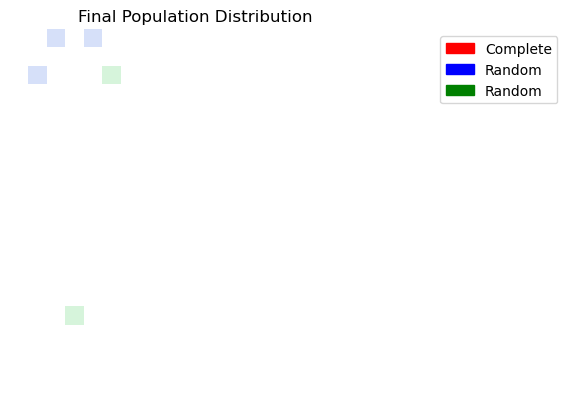

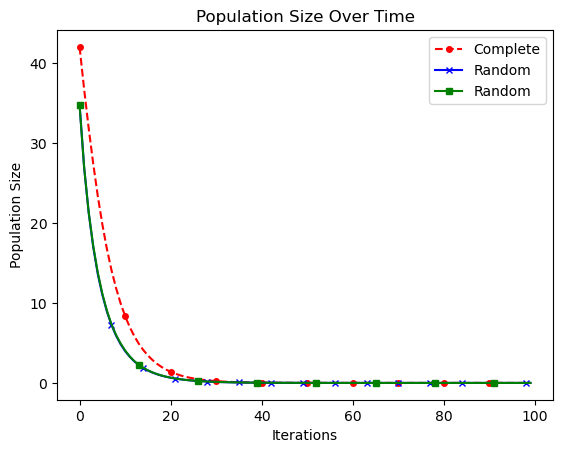

Creating simulation: complete vs giving vs attacking


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5698748588562011..1.0000000149011612].



Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 32.68206024169922

Total fitness: 32.68206024169922

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



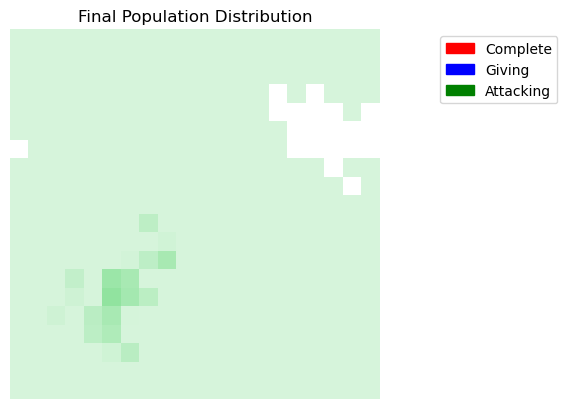

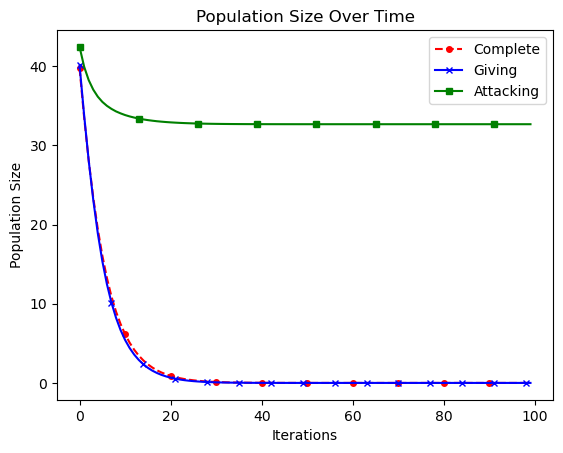

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.36713242530822754..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.99187469482422
Population 2: random - 7.519425707869232e-06
Population 3: random - 7.089603059284855e-06

Total fitness: 44.99188995361328

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



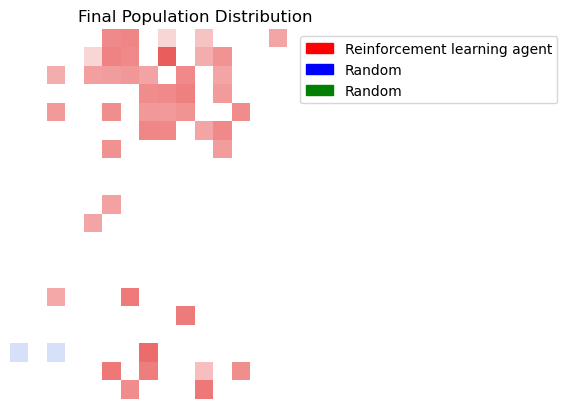

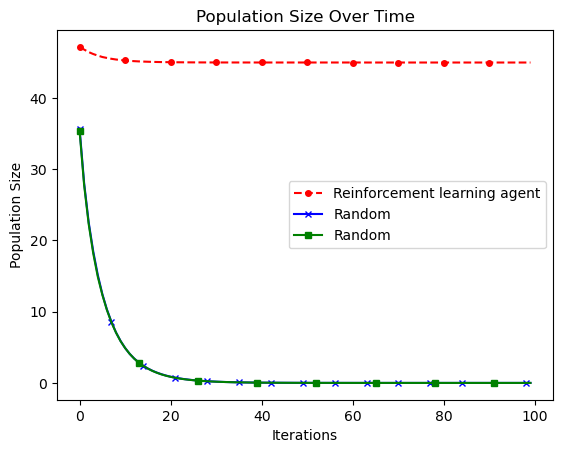

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.48476171493530273..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 20.79058074951172
Population 2: attacking - 26.463045120239258
Population 3: attacking - 27.118181228637695

Total fitness: 74.3718032836914

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 27.95%
Population 2: attacking - 35.58%
Population 3: attacking - 36.46%



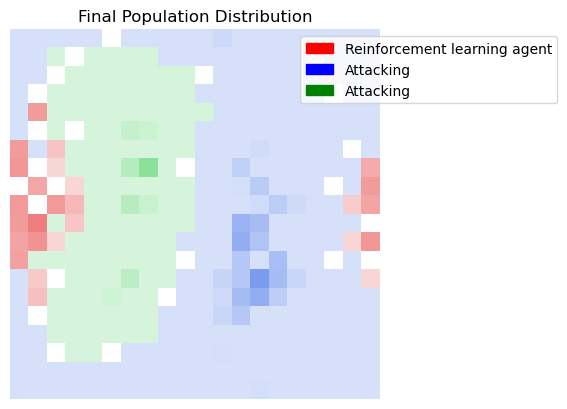

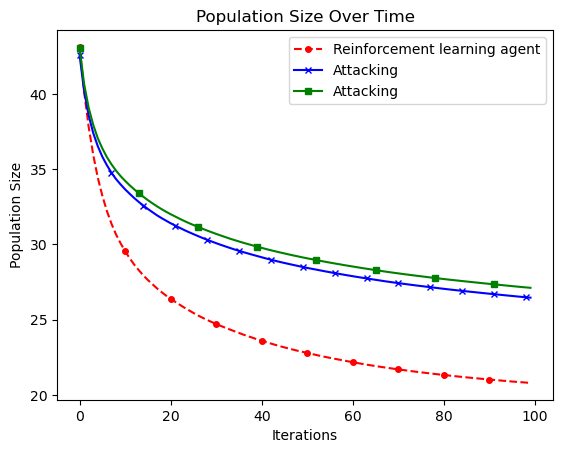

Creating simulation with parameters: bonus_0_1 - fitness_donation: 0.0 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3614.07080078125
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3614.07080078125

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



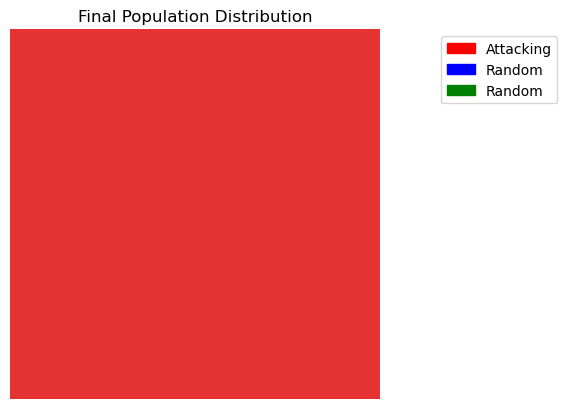

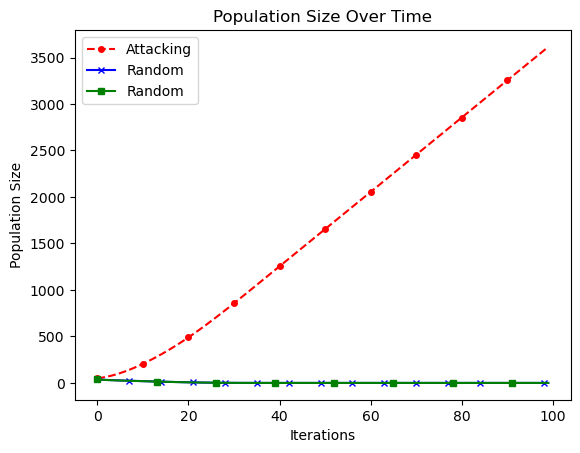

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 224.95458984375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.95458984375

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



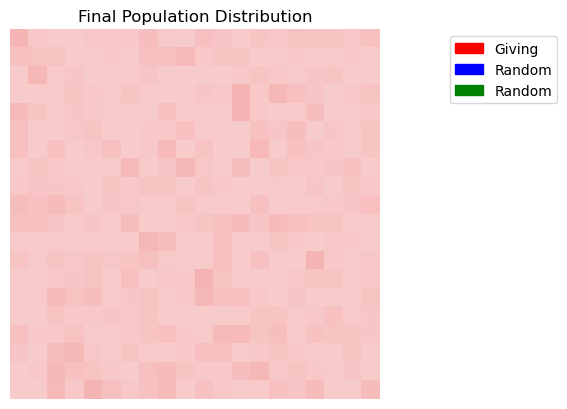

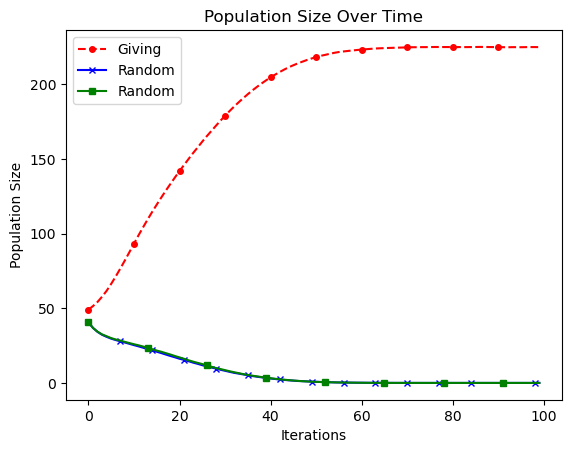

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 224.8902130126953
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.8902130126953

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



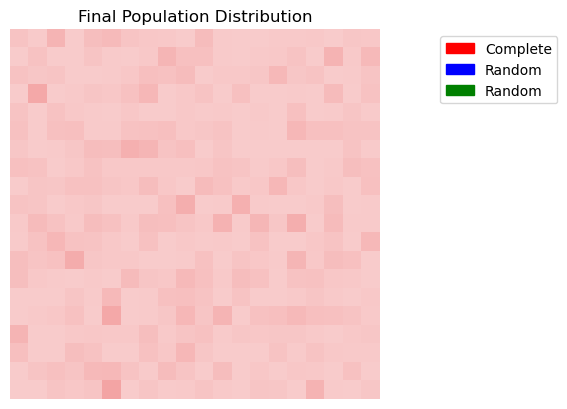

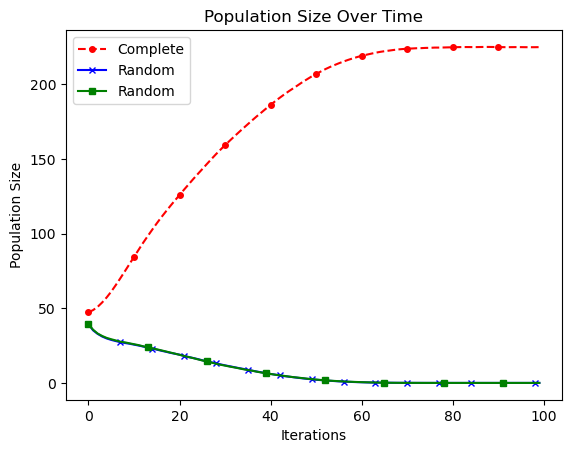

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 3008.837890625

Total fitness: 3008.837890625

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



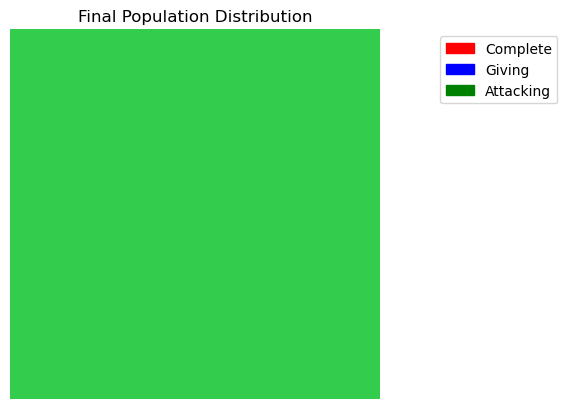

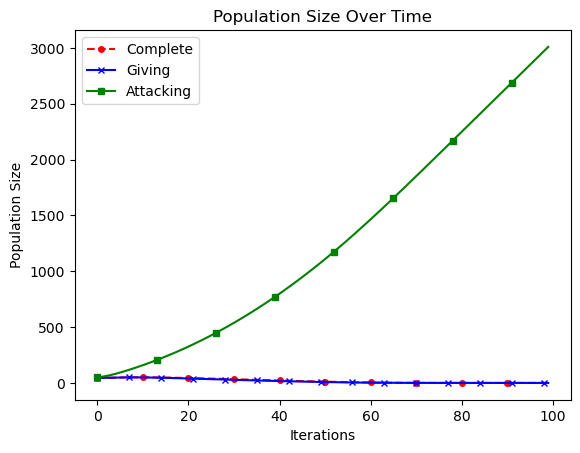

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 455.1602783203125
Population 2: random - 44.82282257080078
Population 3: random - 45.49725341796875

Total fitness: 545.4803466796875

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 83.44%
Population 2: random - 8.22%
Population 3: random - 8.34%



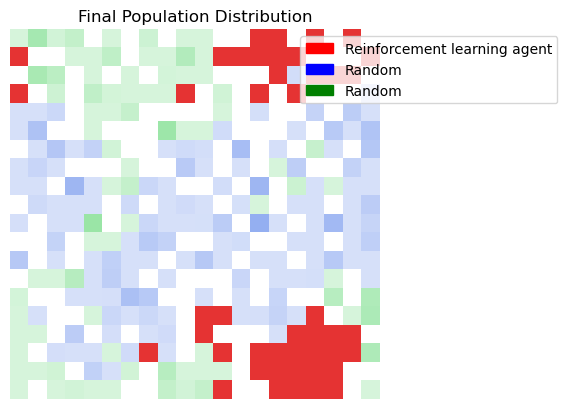

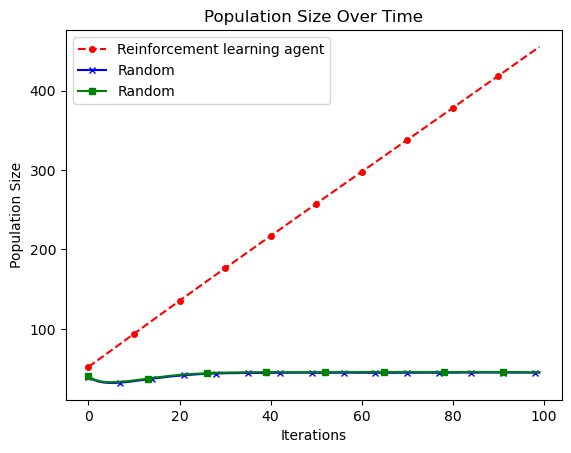

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.9999715685844421
Population 2: attacking - 1233.579833984375
Population 3: attacking - 1311.0511474609375

Total fitness: 2545.630859375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.04%
Population 2: attacking - 48.46%
Population 3: attacking - 51.50%



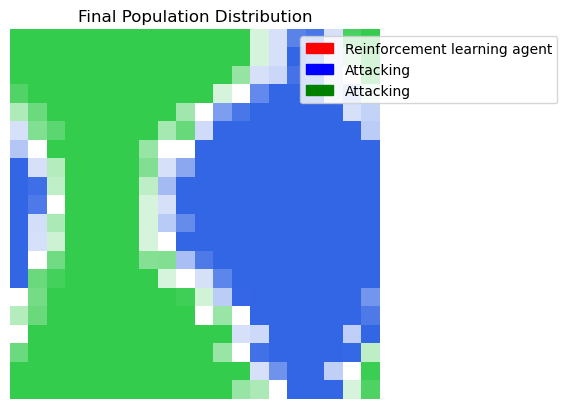

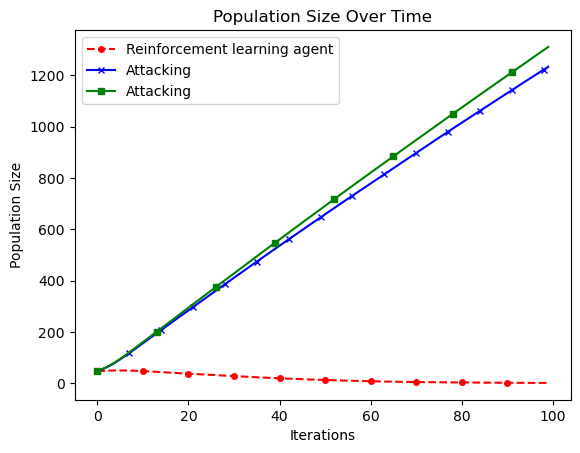

Creating simulation with parameters: bonus_1_0 - fitness_donation: 0.1 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 38.338340759277344
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 38.338340759277344

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



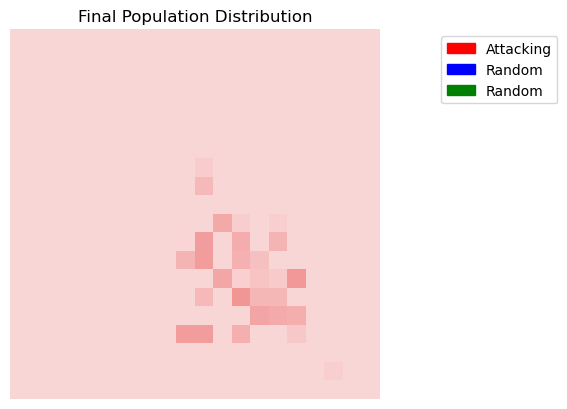

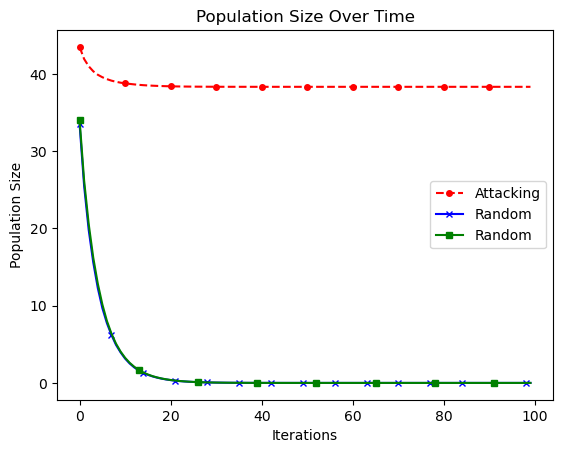

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 1.0185439123233664e-06
Population 2: random - 1.2481593330448959e-05
Population 3: random - 1.3088590094412211e-05

Total fitness: 2.6588728360366076e-05

Final population %'s fitness:
Population 1: giving - 3.83%
Population 2: random - 46.94%
Population 3: random - 49.23%



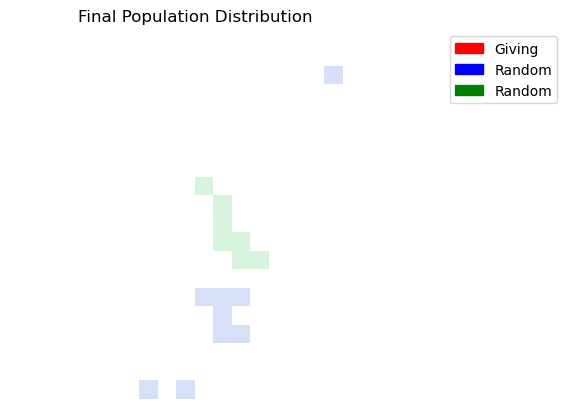

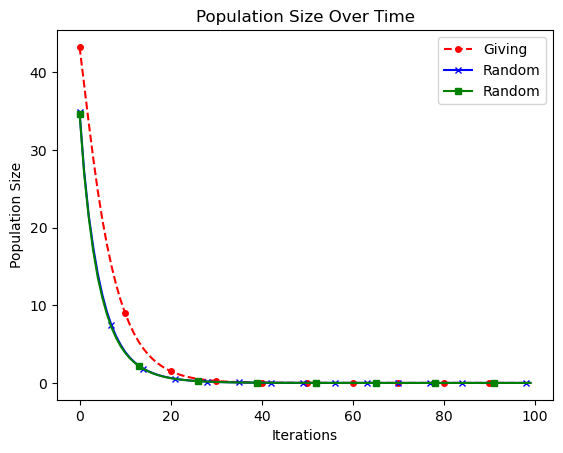

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 7.215383135417142e-08
Population 2: random - 5.45587090527988e-06
Population 3: random - 6.170269443828147e-06

Total fitness: 1.169829374703113e-05

Final population %'s fitness:
Population 1: complete - 0.62%
Population 2: random - 46.64%
Population 3: random - 52.75%



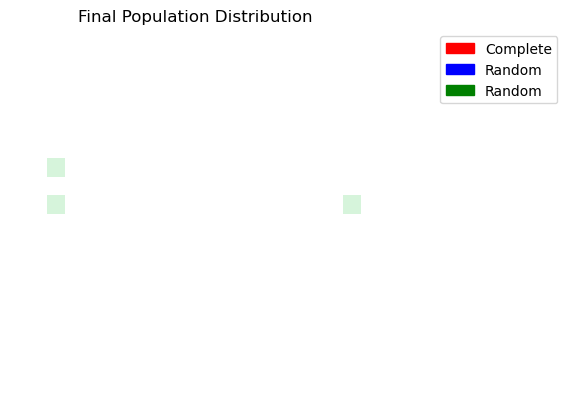

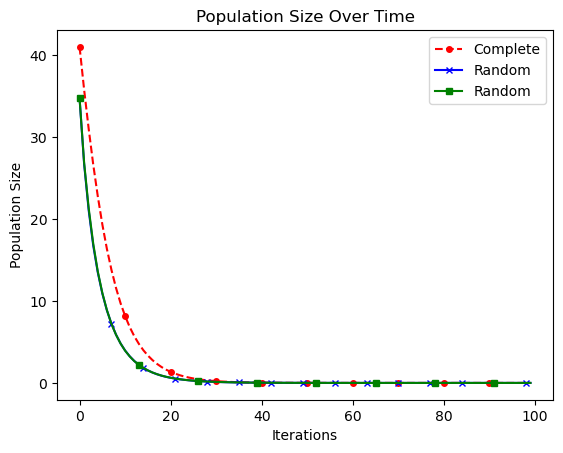

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 6.329228199319914e-07
Population 2: giving - 0.0
Population 3: attacking - 33.669620513916016

Total fitness: 33.669620513916016

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



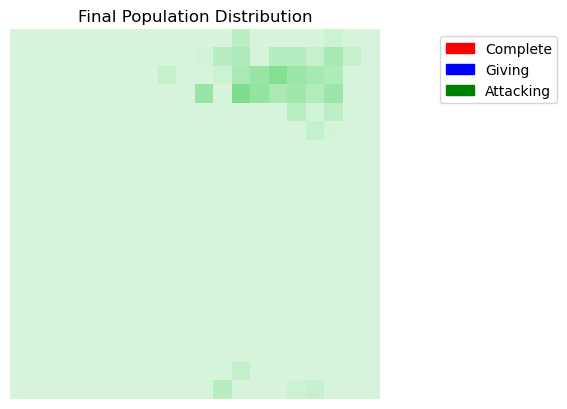

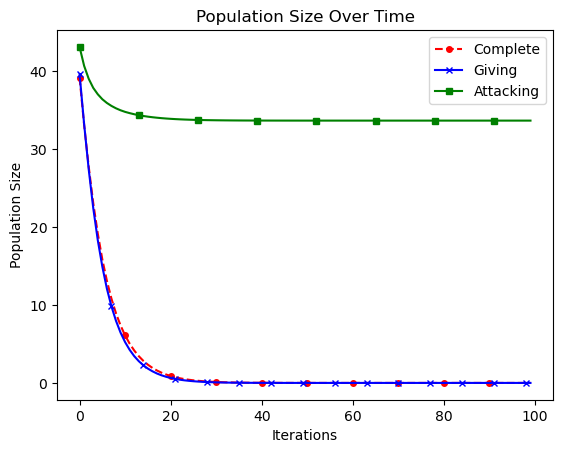

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38227238655090334..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.80085754394531
Population 2: random - 8.483304554829374e-06
Population 3: random - 1.0900827874138486e-05

Total fitness: 44.80087661743164

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



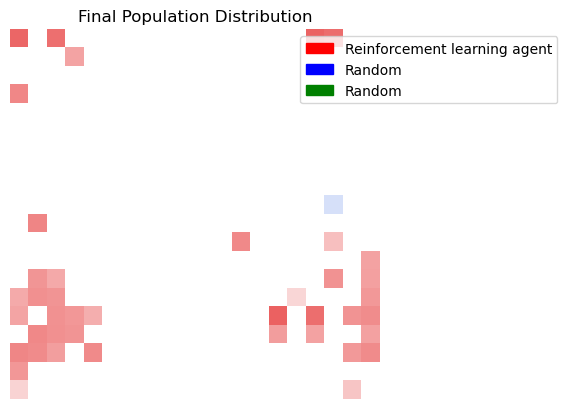

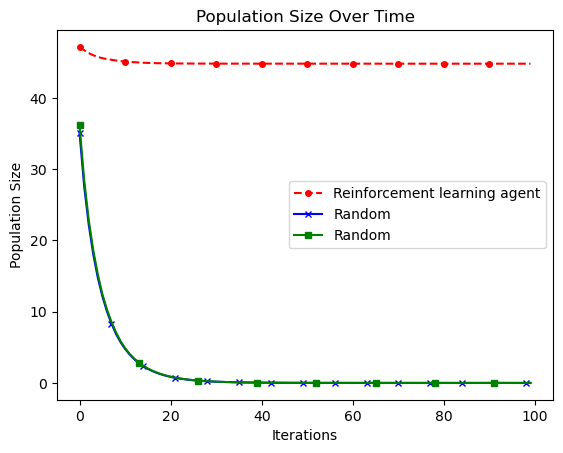

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5533707141876221..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 20.530824661254883
Population 2: attacking - 25.99717903137207
Population 3: attacking - 26.67105484008789

Total fitness: 73.19905853271484

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 28.05%
Population 2: attacking - 35.52%
Population 3: attacking - 36.44%



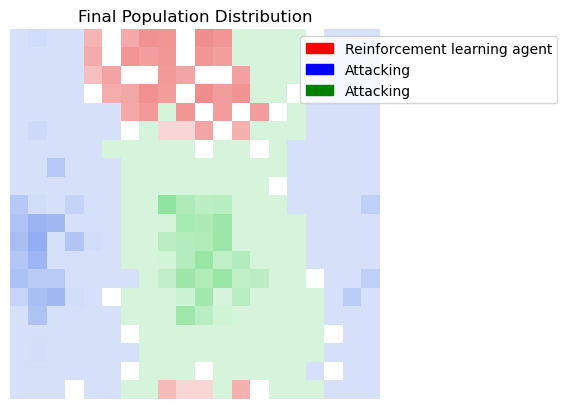

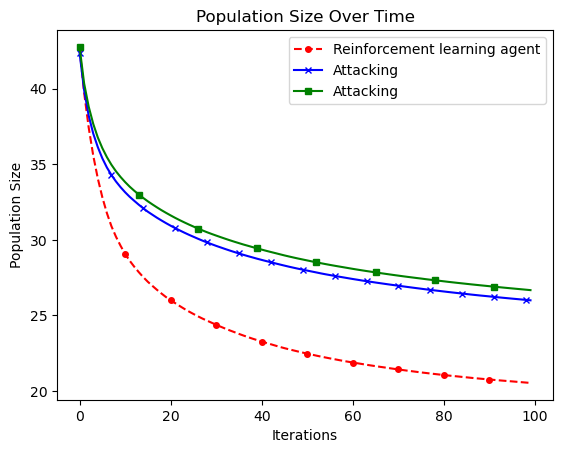

Creating simulation with parameters: bonus_1_1 - fitness_donation: 0.1 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3617.45849609375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3617.45849609375

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



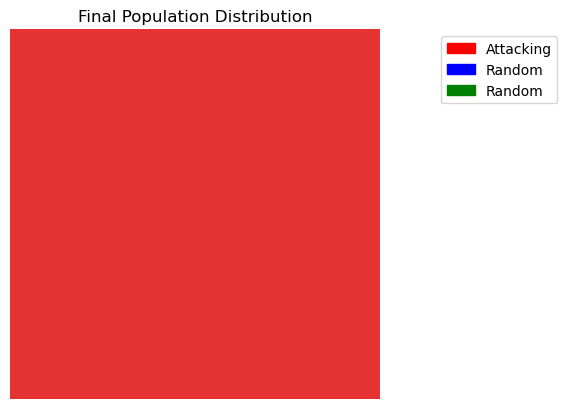

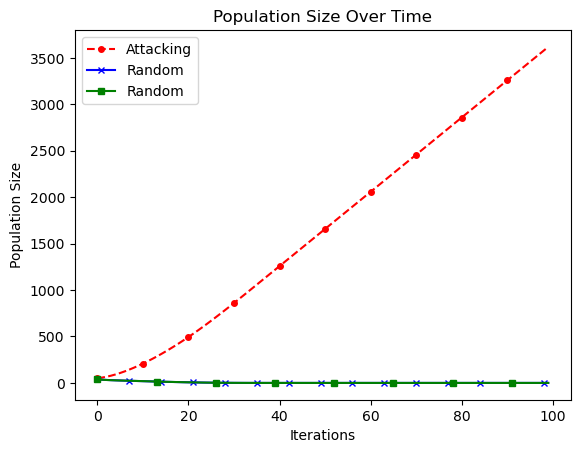

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 224.92648315429688
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.92648315429688

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



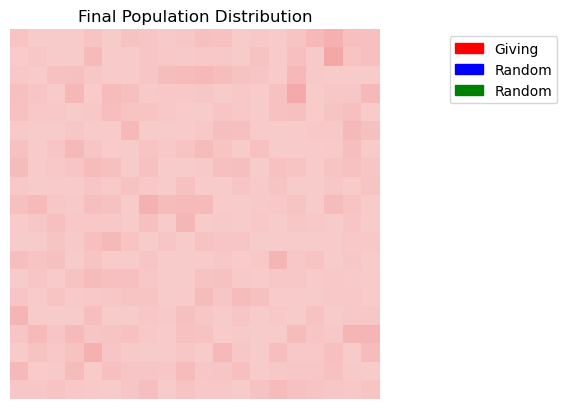

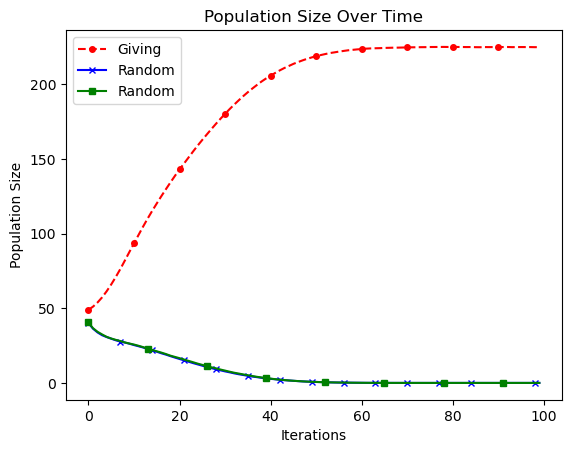

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 224.9300079345703
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.9300079345703

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



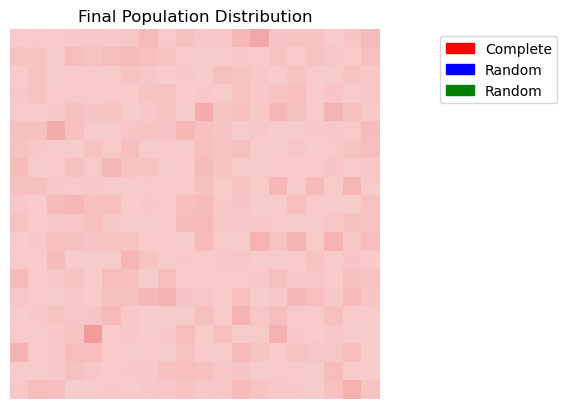

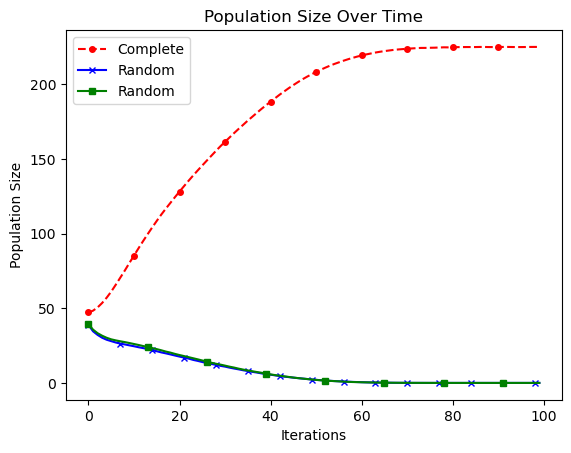

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0010617122752591968
Population 2: giving - 0.0
Population 3: attacking - 3015.18017578125

Total fitness: 3015.18115234375

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



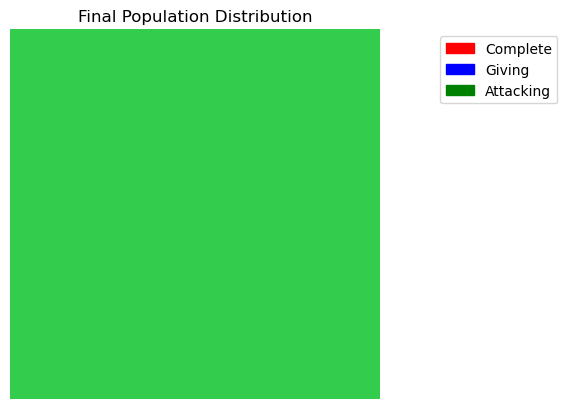

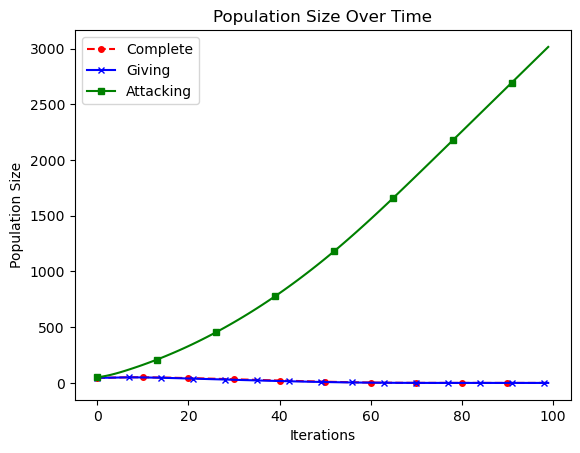

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 451.7459411621094
Population 2: random - 45.28972625732422
Population 3: random - 45.019195556640625

Total fitness: 542.0548706054688

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 83.34%
Population 2: random - 8.36%
Population 3: random - 8.31%



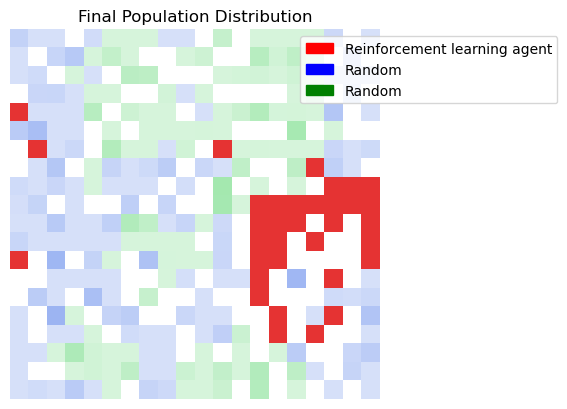

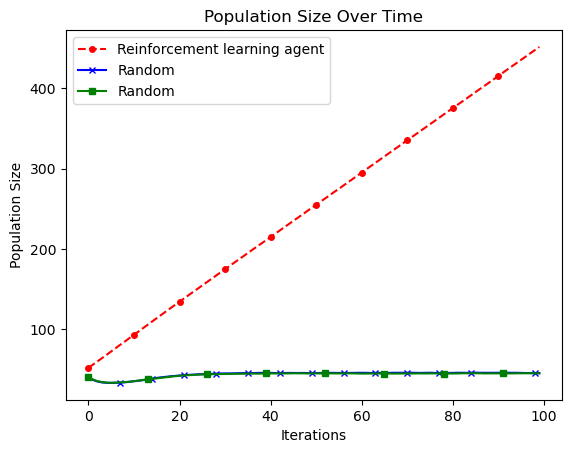

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.8731932640075684
Population 2: attacking - 1293.9715576171875
Population 3: attacking - 1241.515625

Total fitness: 2536.3603515625

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.03%
Population 2: attacking - 51.02%
Population 3: attacking - 48.95%



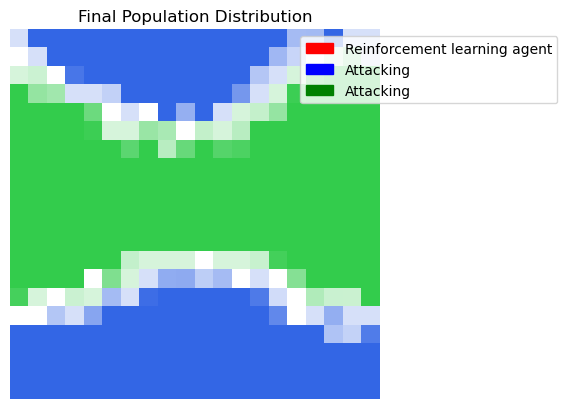

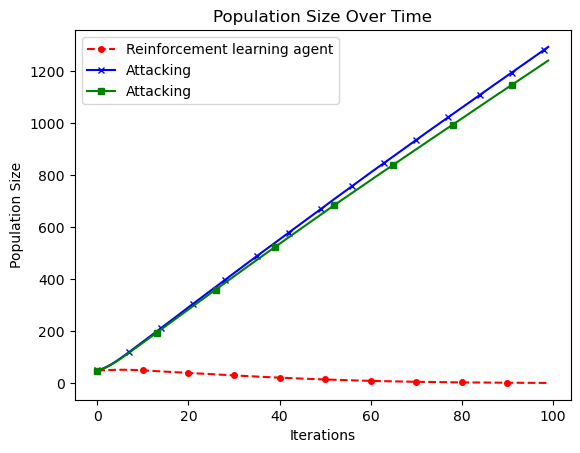

Creating simulation with parameters: bonus_2_0 - fitness_donation: 0.2 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.59068298339844
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.59068298339844

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



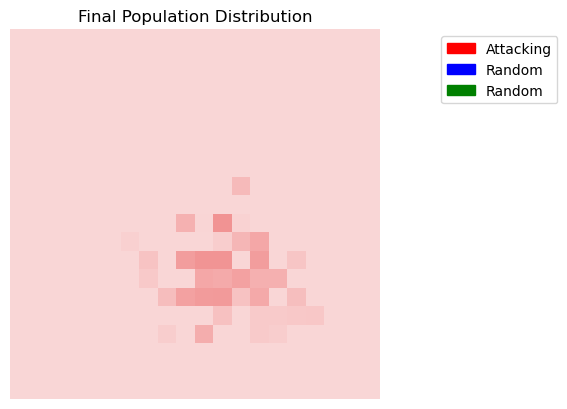

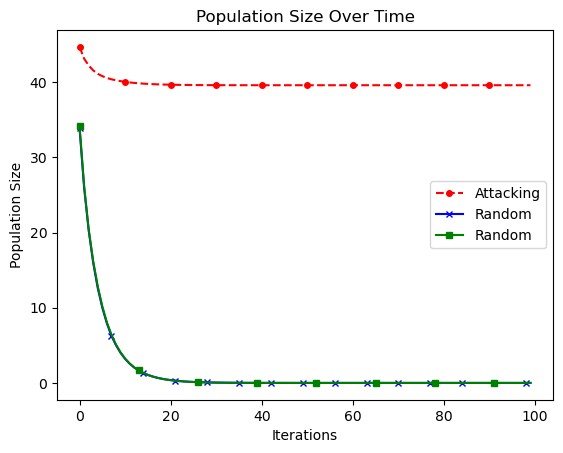

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 7.622883231306332e-07
Population 2: random - 1.2083832189091481e-05
Population 3: random - 1.3199281056586187e-05

Total fitness: 2.604540168249514e-05

Final population %'s fitness:
Population 1: giving - 2.93%
Population 2: random - 46.40%
Population 3: random - 50.68%



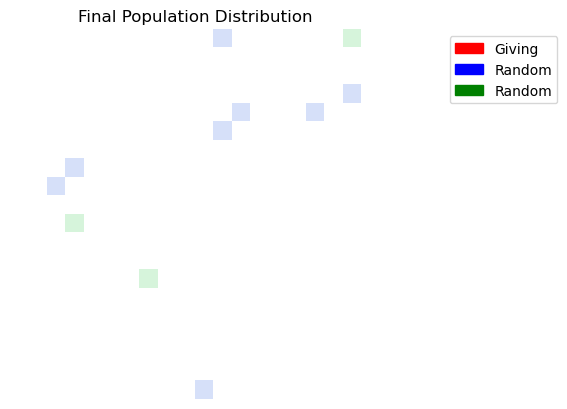

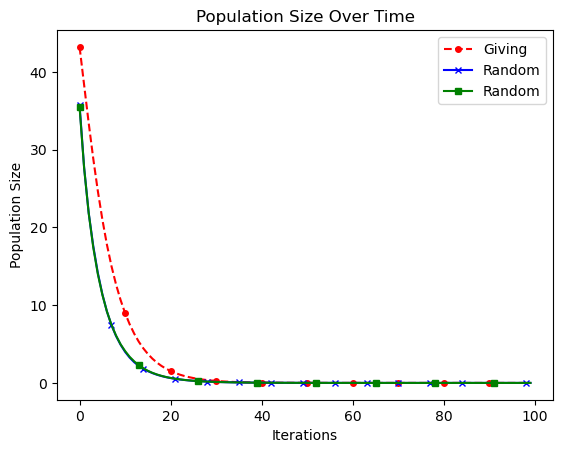

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 1.419881101583087e-07
Population 2: random - 5.238093763182405e-06
Population 3: random - 7.234773875097744e-06

Total fitness: 1.2614855222636834e-05

Final population %'s fitness:
Population 1: complete - 1.13%
Population 2: random - 41.52%
Population 3: random - 57.35%



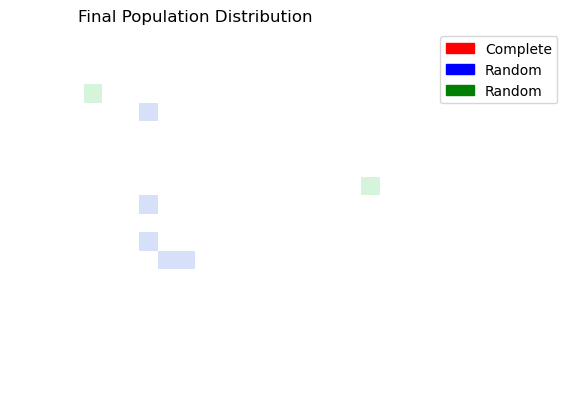

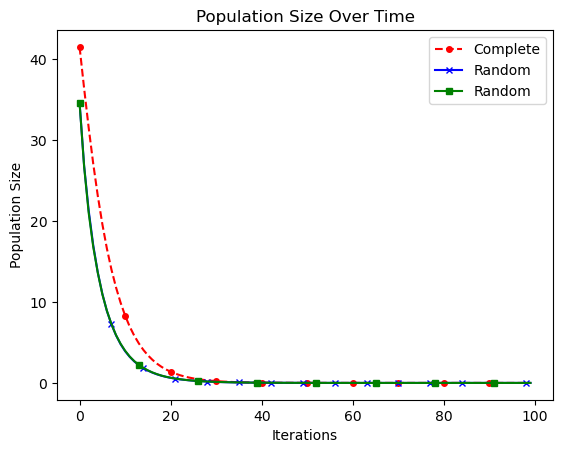

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 33.66817092895508

Total fitness: 33.66817092895508

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



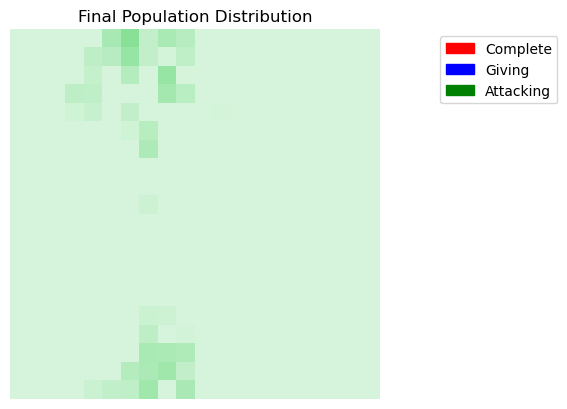

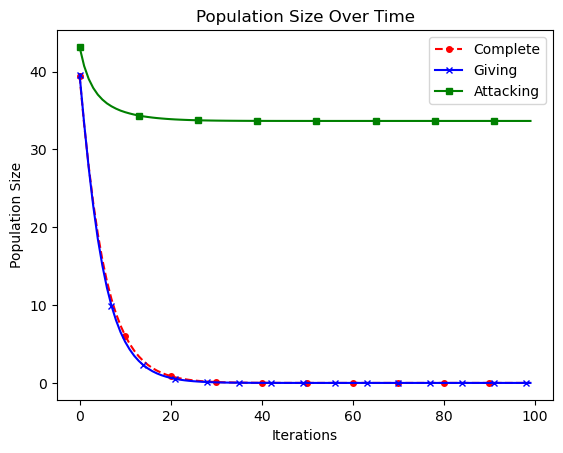

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3903221130371094..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.048255920410156
Population 2: random - 1.0466279491083696e-05
Population 3: random - 8.356935722986236e-06

Total fitness: 44.048274993896484

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



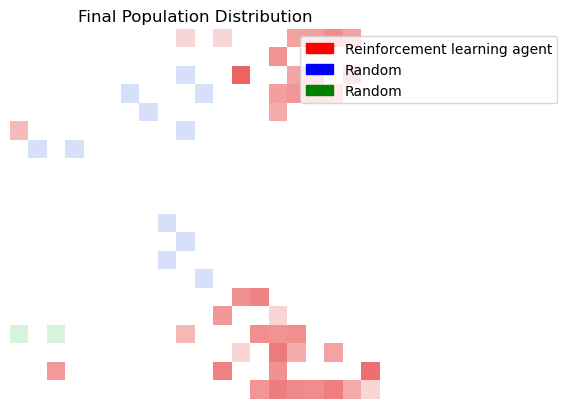

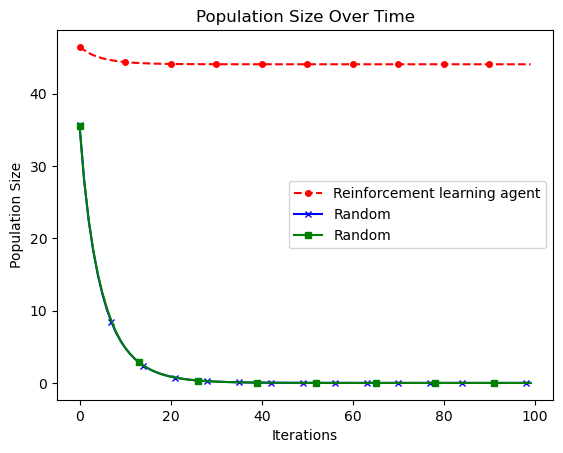

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.35503854751586916..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 21.025367736816406
Population 2: attacking - 27.392845153808594
Population 3: attacking - 26.278648376464844

Total fitness: 74.69686126708984

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 28.15%
Population 2: attacking - 36.67%
Population 3: attacking - 35.18%



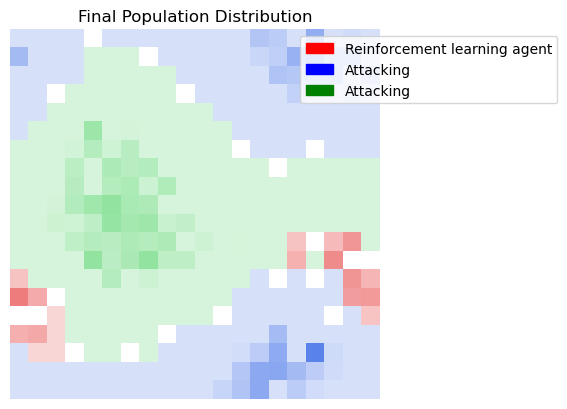

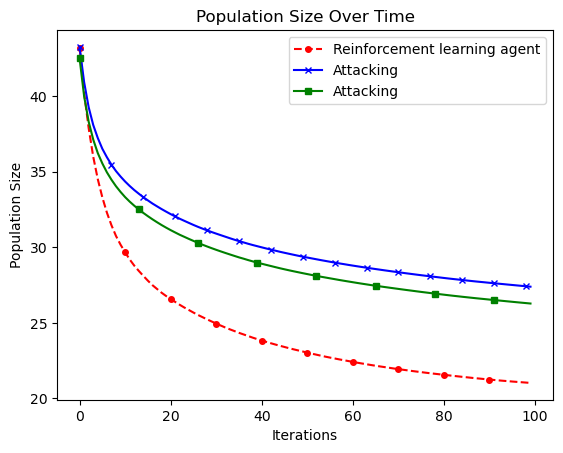

Creating simulation with parameters: bonus_2_1 - fitness_donation: 0.0 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7201.400390625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7201.400390625

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



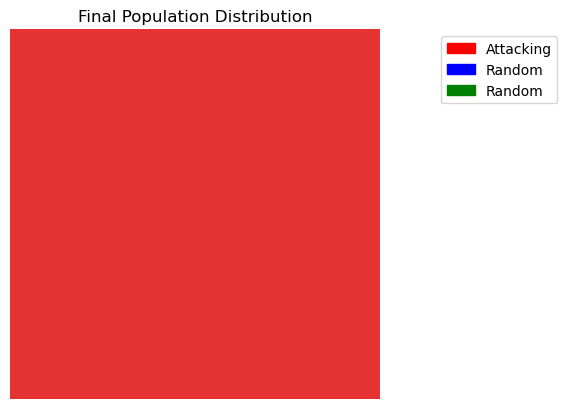

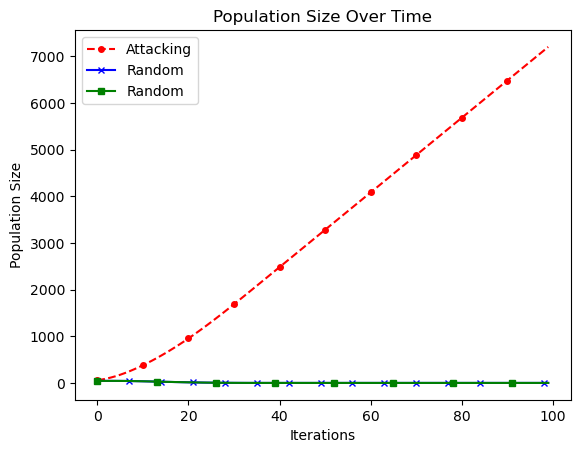

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 449.96734619140625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.96734619140625

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



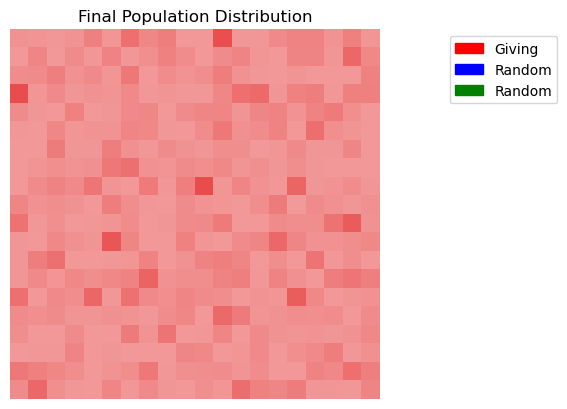

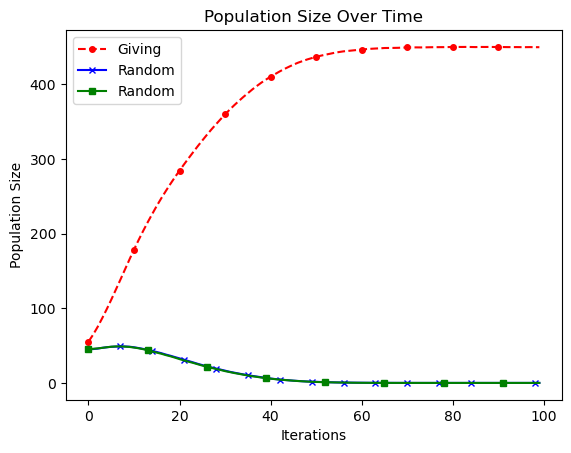

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 449.85382080078125
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.85382080078125

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



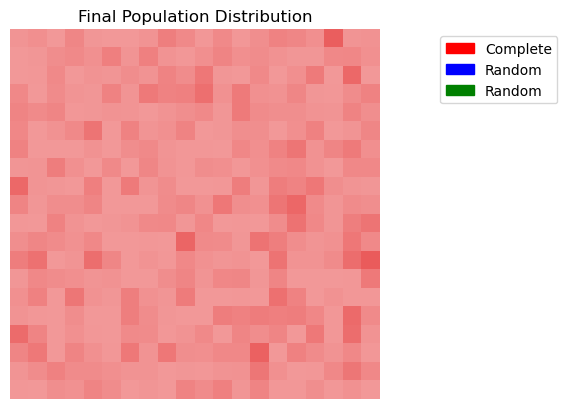

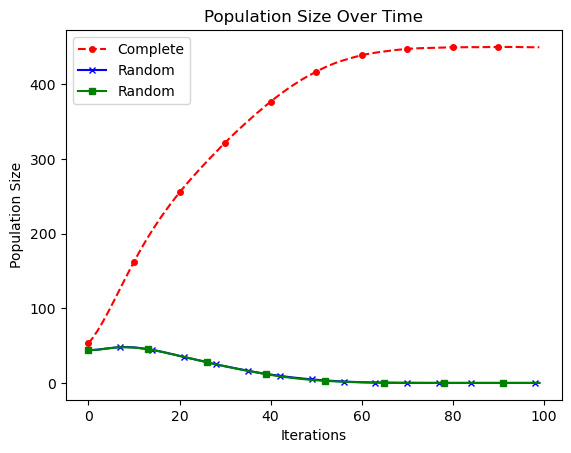

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 5988.529296875

Total fitness: 5988.529296875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



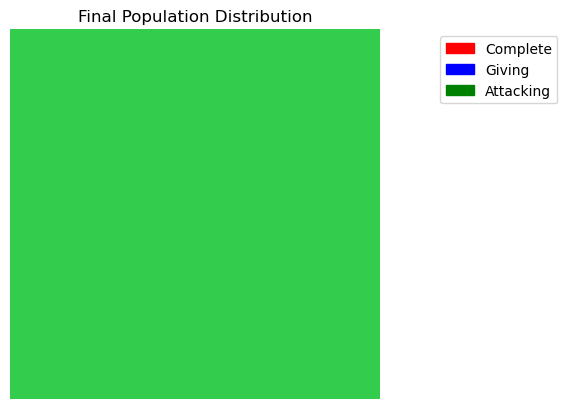

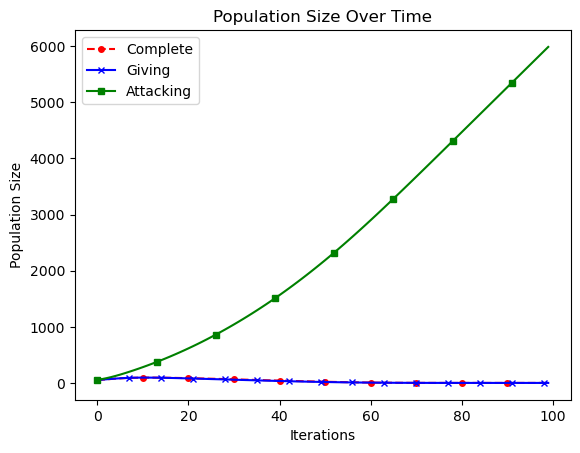

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 860.115966796875
Population 2: random - 91.40972900390625
Population 3: random - 89.7158432006836

Total fitness: 1041.2415771484375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 82.60%
Population 2: random - 8.78%
Population 3: random - 8.62%



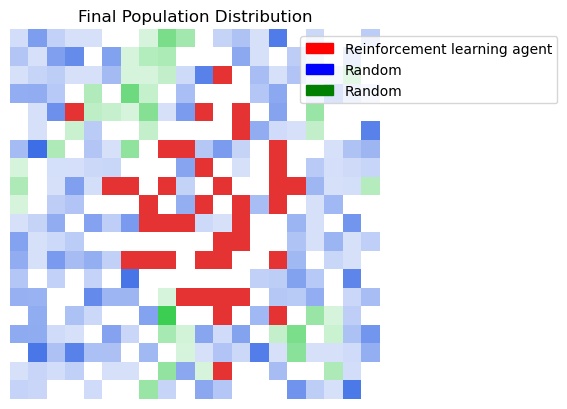

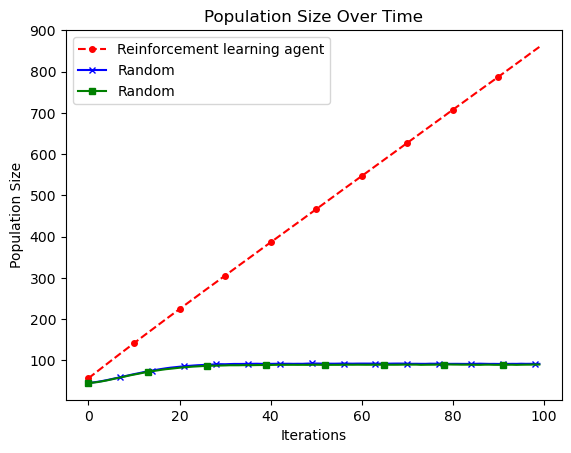

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.43542563915252686
Population 2: attacking - 2564.003662109375
Population 3: attacking - 2512.941650390625

Total fitness: 5077.380859375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.01%
Population 2: attacking - 50.50%
Population 3: attacking - 49.49%



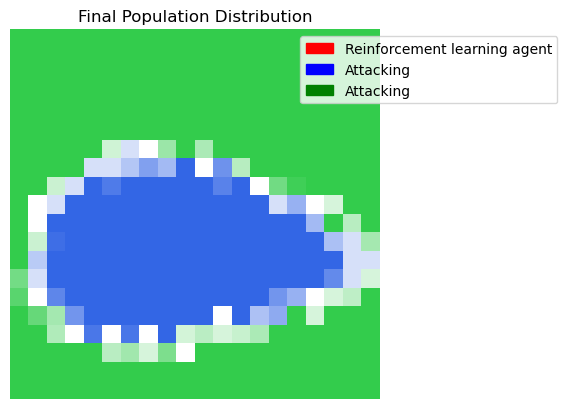

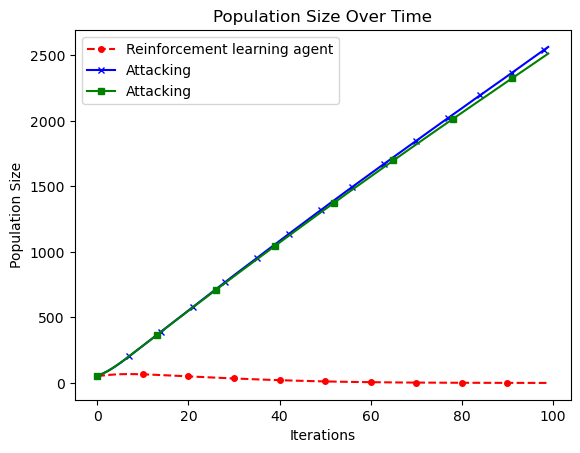

Creating simulation with parameters: bonus_2_2 - fitness_donation: 0.2 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7202.4384765625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7202.4384765625

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



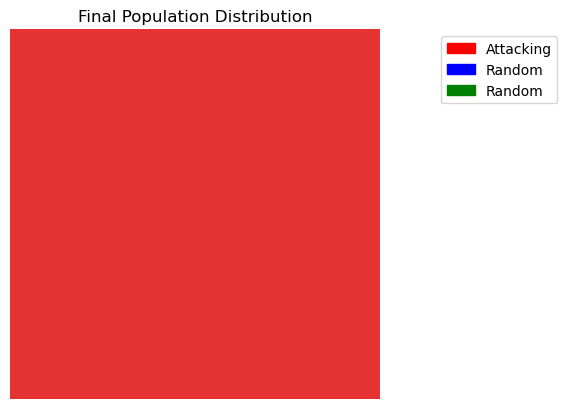

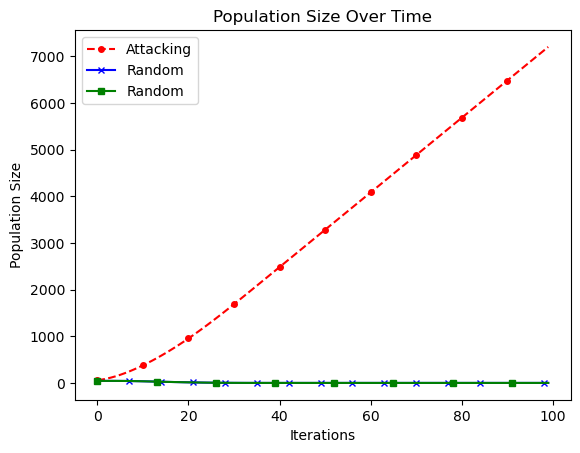

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 449.7459411621094
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.7459411621094

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



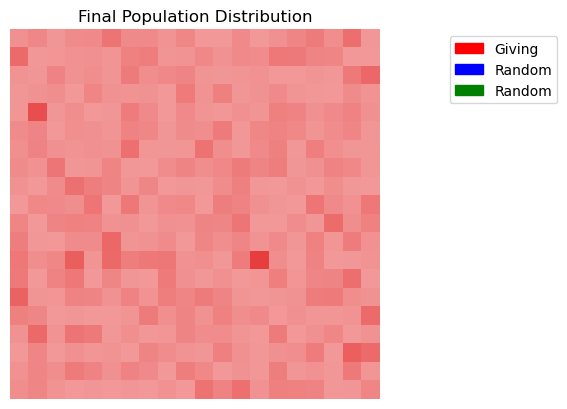

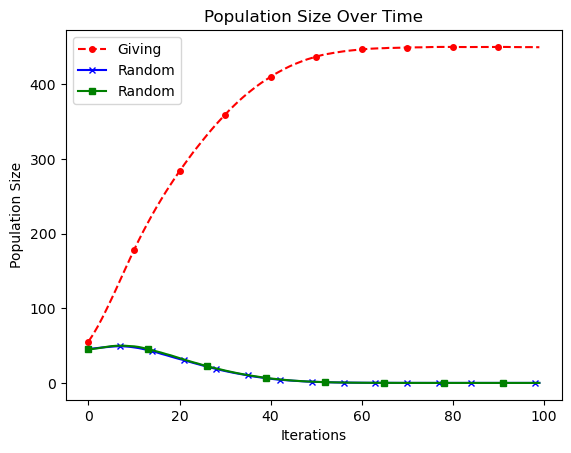

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 450.0350036621094
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 450.0350036621094

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



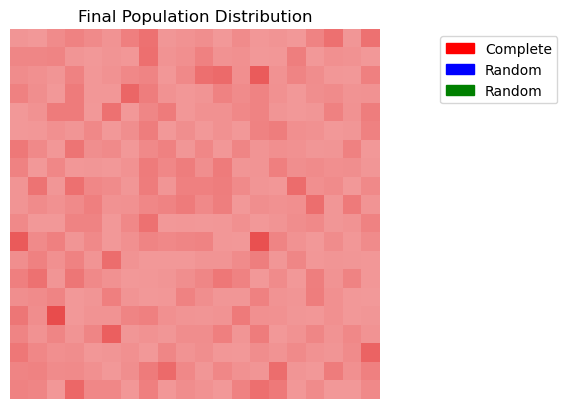

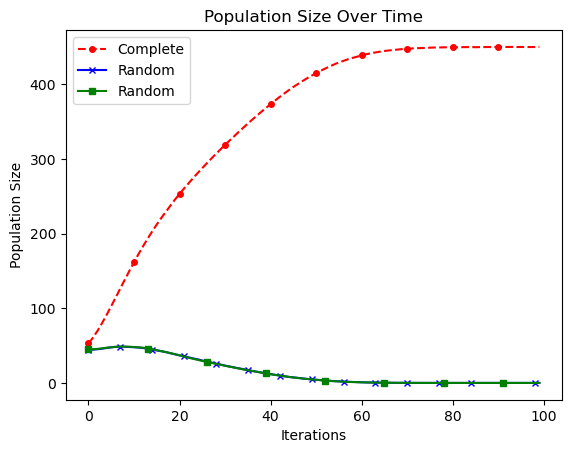

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0006968547240830958
Population 2: giving - 0.027414072304964066
Population 3: attacking - 6024.865234375

Total fitness: 6024.8935546875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



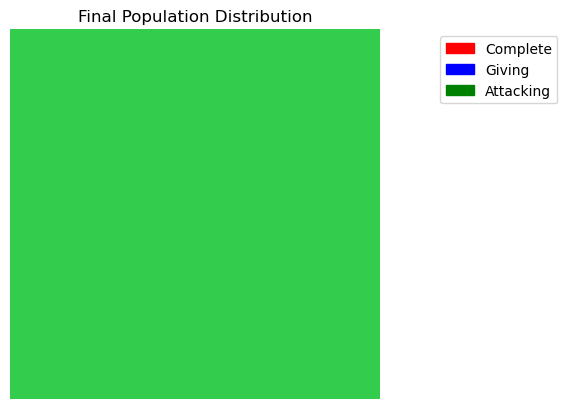

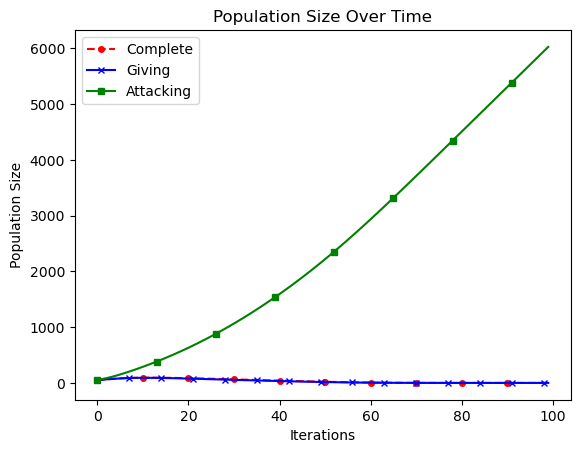

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 843.4371948242188
Population 2: random - 88.45337677001953
Population 3: random - 92.74400329589844

Total fitness: 1024.634521484375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 82.32%
Population 2: random - 8.63%
Population 3: random - 9.05%



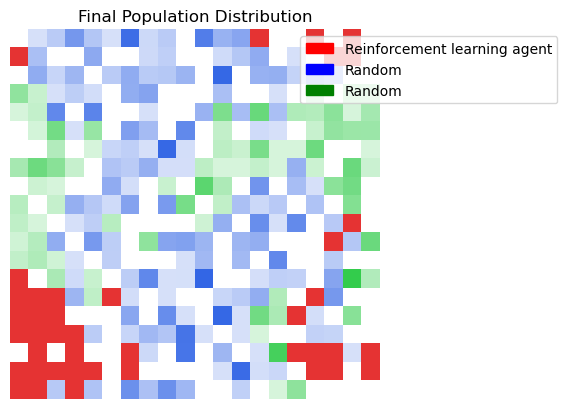

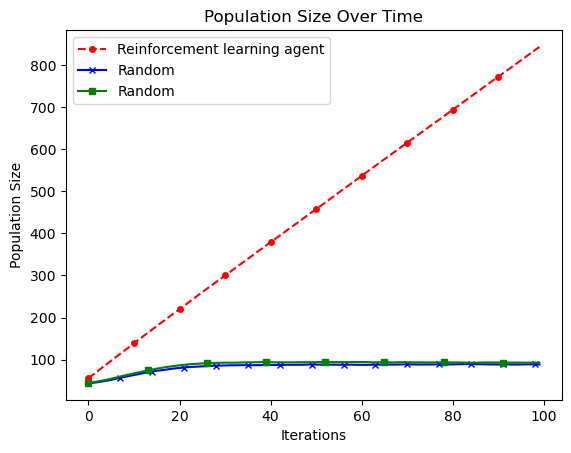

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.8916504383087158
Population 2: attacking - 2474.57958984375
Population 3: attacking - 2593.359130859375

Total fitness: 5068.830078125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.02%
Population 2: attacking - 48.82%
Population 3: attacking - 51.16%



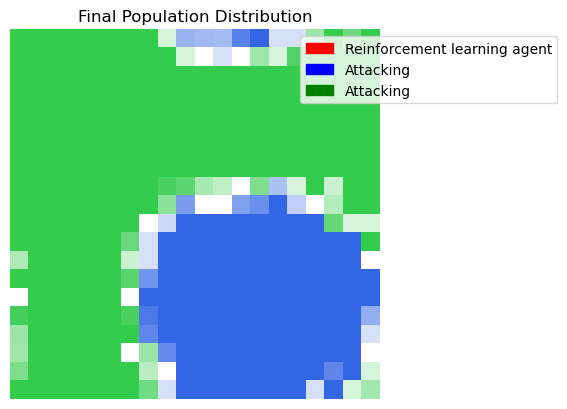

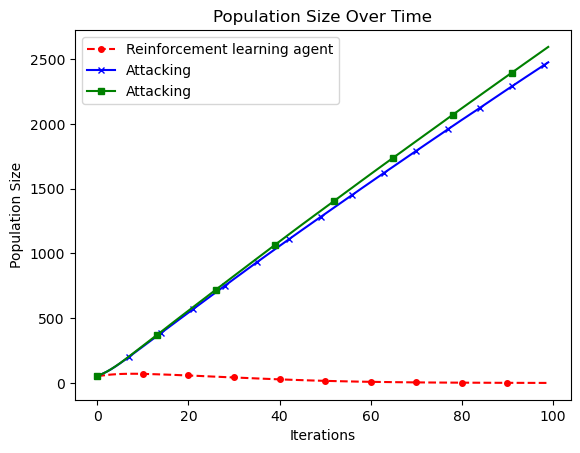

In [17]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_1', 0.0, 0.1), ('bonus_1_0', 0.1, 0.0), ('bonus_1_1', 0.1, 0.1), ('bonus_2_0', 0.2, 0.0), ('bonus_2_1', 0.0, 0.2), ('bonus_2_2', 0.2, 0.2)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 100

# Simulation parameters
nb_batches = 300
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Complete vs Giving vs Attacking\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "Clever vs Random"
    print("Creating simulation: Reinforcement Learning Agent vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='random', type3='random', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Attacker")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsAttacker')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='attacking', type3='attacking', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Attacker\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)
